In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [2]:
df = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\Etapa3\acidentes_pbic_2020_2025_Final.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df.shape)


Shape inicial: (1678326, 48)


In [3]:
df_map = df.copy()

In [4]:
df["severity_index"] = (
    4 * df["mortos"] +
    2 * df["feridos_graves"] +
    1 * df["feridos_leves"]
)

In [5]:
# --- Target transformada para ML ---
df["severity_index_log"] = np.log1p(df["severity_index"])

In [6]:
# --- Target transformada para ML ---
df["severity_index"] = df["severity_index_log"]

In [7]:
df["km"] = (
    df["km"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["km"] = pd.to_numeric(df["km"], errors="coerce")

#df = df.dropna(subset=["km"])

In [8]:
linhas_invalidas = df[["km"]].isna().any(axis=1).sum()
print(f"Linhas inválidas removidas: {linhas_invalidas}")

Linhas inválidas removidas: 4804


In [9]:
df = df.dropna(subset=["km"])

In [10]:
linhas_invalidas = df[["km"]].isna().any(axis=1).sum()
print(f"Linhas inválidas removidas: {linhas_invalidas}")

Linhas inválidas removidas: 0


In [11]:
df["km_bin"] = (df["km"] // 5) * 5   # segmentos de 5 km

In [12]:
import numpy as np

df_segmento = df.groupby(["br", "km_bin"]).agg({
    "severity_index": "mean",
    "id": "count"
}).reset_index()

df_segmento.rename(columns={"id": "n_acidentes"}, inplace=True)

In [13]:
print("Linhas atuais:", len(df))

Linhas atuais: 1673522


In [14]:
df_segmento["score_risco"] = ( df_segmento["severity_index"] * np.log1p(df_segmento["n_acidentes"]))

In [15]:
df_segmento = df_segmento.sort_values("score_risco", ascending=False)

df_segmento.head(20)

,br,km_bin,severity_index,n_acidentes,score_risco
4987,349.0,885.0,1.354025,54,5.426030
3898,282.0,285.0,1.107748,133,5.425570
4455,308.0,160.0,1.233815,72,5.293633
3253,251.0,425.0,0.933353,272,5.235617
6366,405.0,20.0,1.158103,89,5.211241
5131,361.0,30.0,1.351818,44,5.145914
6388,405.0,130.0,1.222507,64,5.103218
1432,135.0,600.0,1.112550,95,5.078064
6172,392.0,200.0,1.138269,82,5.029828
2170,163.0,1100.0,0.993927,138,4.904509


In [16]:
df["severity_log"] = np.log1p(df["severity_index"])

In [17]:
df = df[df["severity_index"] >= 0]

In [18]:
df["idade_veiculo"] = 2025 - df["ano_fabricacao_veiculo"]

In [19]:
df["latitude"] = (
    df["latitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["longitude"] = (
    df["longitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

In [20]:
print("Latitudes inválidas:", df["latitude"].isna().sum())
print("Longitudes inválidas:", df["longitude"].isna().sum())

Latitudes inválidas: 0
Longitudes inválidas: 0


In [21]:
print("Linhas atuais:", len(df))

Linhas atuais: 1673522


In [22]:
features = [
    "uf",
    "br",
    "km",
    "hora",
    "mes",
    "dia_semana",
    #"tipo_acidente",
    "fase_dia",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo", #*
    "tipo_veiculo",
    "idade",
    "idade_veiculo",
    'latitude', 
    'longitude',
    'regional', 
    'Fabricante',
    'Modelo'
]

In [23]:
df = df.dropna(subset=["severity_log"])

for col in features:
    
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
        
    else:
        df[col] = df[col].fillna("Desconhecido")

In [24]:
categoricas = df[features].select_dtypes(include="object").columns

for col in categoricas:
    df[col] = df[col].astype("category")

C:\Users\fause\AppData\Local\Temp\ipykernel_6672\1339650400.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df[features].select_dtypes(include="object").columns


In [25]:
X = df[features]
y = df["severity_log"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
import lightgbm as lgb

modelo = lgb.LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42,
    n_jobs=-1,
    force_col_wise=True,
    max_bin=512

)

# modelo = lgb.LGBMRegressor(
#     n_estimators=800,          # mais árvores
#     learning_rate=0.03,        # aprendizado mais suave
#     num_leaves=128,            # mais capacidade
#     max_depth=-1,              # sem limite explícito
#     min_child_samples=40,      # evita overfitting
#     subsample=0.8,             # bagging
#     colsample_bytree=0.8,      # feature sampling
#     reg_alpha=0.5,             # regularização L1
#     reg_lambda=0.5,            # regularização L2
#     random_state=42,
#     n_jobs=-1,
#     force_col_wise=True,
#     max_bin=512
# )

modelo.fit(X_train, y_train)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Total Bins 3037
[LightGBM] [Info] Number of data points in the train set: 1338817, number of used features: 19
[LightGBM] [Info] Start training from score 0.310282


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.05
,n_estimators,400
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


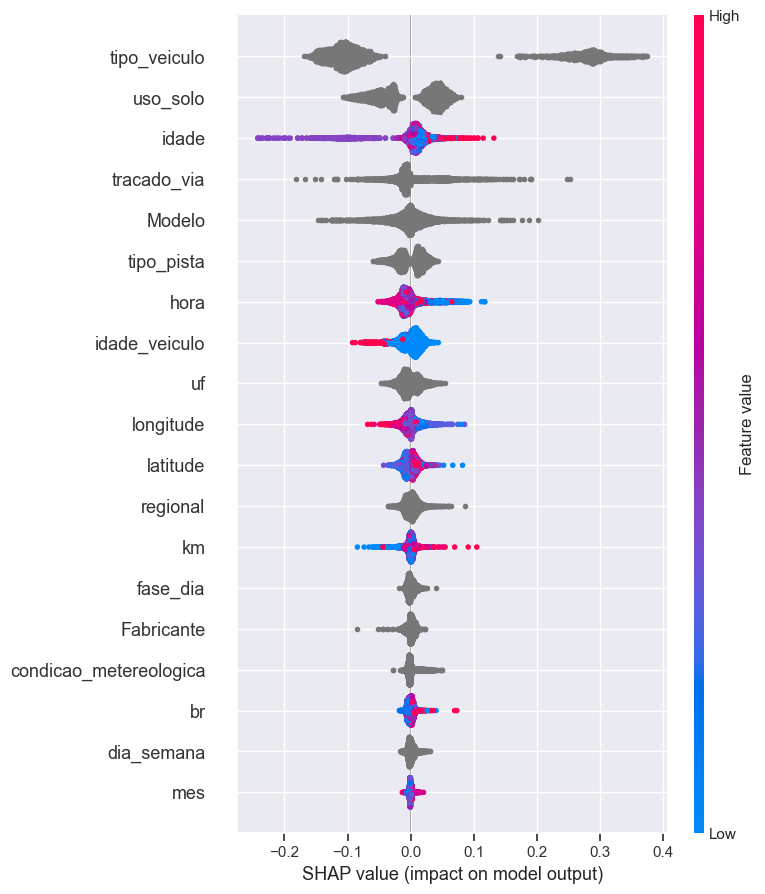

In [28]:
import shap
import numpy as np

# pegar amostra aleatória pequena
X_sample = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

In [29]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

pred = modelo.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.23493246573517845
R2: 0.48913729393387684


In [30]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(modelo, X, y, cv=kf, scoring='r2')

print("R2 por fold:", r2_scores)
print("R2 médio:", np.mean(r2_scores))
print("Desvio padrão:", np.std(r2_scores))

rmse_scores = -cross_val_score(modelo, X, y, cv=kf,
                                scoring='neg_root_mean_squared_error')

print("RMSE médio:", np.mean(rmse_scores))

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Total Bins 3026
[LightGBM] [Info] Number of data points in the train set: 1338817, number of used features: 19
[LightGBM] [Info] Start training from score 0.310282
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Total Bins 3021
[LightGBM] [Info] Number of data points in the train set: 1338817, number of used features: 19
[LightGBM] [Info] Start training from score 0.309954
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_f

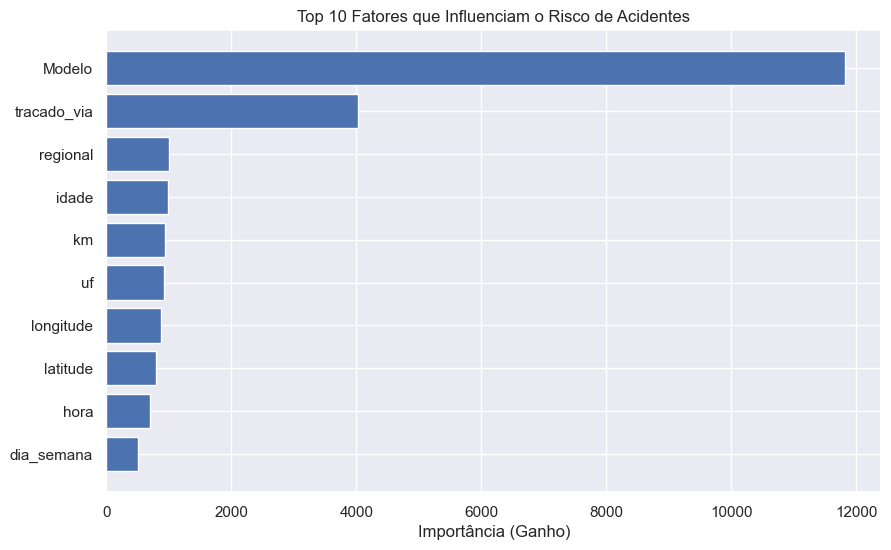

In [31]:
import matplotlib.pyplot as plt

# Pegando a importância das colunas
importancias = pd.DataFrame({
    'feature': X_train.columns,
    'importancia': modelo.feature_importances_
}).sort_values('importancia', ascending=False)

# Plotando
plt.figure(figsize=(10, 6))
plt.barh(importancias['feature'][:10], importancias['importancia'][:10])
plt.xlabel("Importância (Ganho)")
plt.title("Top 10 Fatores que Influenciam o Risco de Acidentes")
plt.gca().invert_yaxis()
plt.show()

In [32]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": modelo.feature_importances_
}).sort_values("importance", ascending=False)

print(importances)

                   feature  importance
18                  Modelo       11812
9              tracado_via        4024
16                regional        1008
12                   idade         992
2                       km         944
0                       uf         917
15               longitude         869
14                latitude         793
3                     hora         696
5               dia_semana         511
13           idade_veiculo         483
1                       br         400
11            tipo_veiculo         332
17              Fabricante         323
4                      mes         277
7   condicao_metereologica         260
10                uso_solo         249
8               tipo_pista         190
6                 fase_dia         120


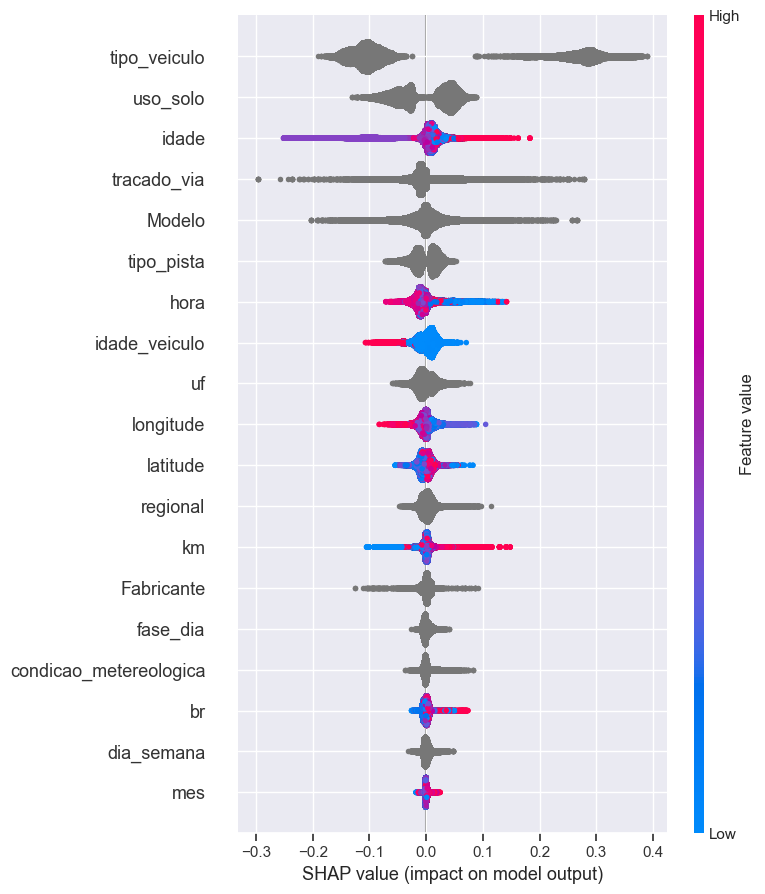

In [33]:
import shap

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [34]:
print("\nSeveridade média por fase do dia:")
print(df.groupby("fase_dia")["severity_index"].mean())

print("\nSeveridade média por tipo de pista:")
print(df.groupby("tipo_pista")["severity_index"].mean())

print("\nSeveridade média por condição meteorológica:")
print(df.groupby("condicao_metereologica")["severity_index"].mean())

print("\nTop 10 tipos de acidente mais severos:")
print(
    df.groupby("tipo_acidente")["severity_index"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)


Severidade média por fase do dia:
fase_dia
Amanhecer      0.494492
Anoitecer      0.430197
Plena Noite    0.472237
Pleno dia      0.419296
Name: severity_index, dtype: float64

Severidade média por tipo de pista:
tipo_pista
Dupla       0.392500
Múltipla    0.366538
Simples     0.492939
Name: severity_index, dtype: float64

Severidade média por condição meteorológica:
condicao_metereologica
Chuva               0.434534
Céu Claro           0.445565
Garoa/Chuvisco      0.407590
Granizo             0.188127
Ignorado            0.517518
Neve                0.363772
Nevoeiro/Neblina    0.486673
Nublado             0.436860
Sol                 0.422615
Vento               0.410806
Name: severity_index, dtype: float64

Top 10 tipos de acidente mais severos:
tipo_acidente
Colisão frontal                 0.588497
Atropelamento de Animal         0.573033
Capotamento                     0.557280
Queda de ocupante de veículo    0.532933
Tombamento                      0.530525
Saída de leito carro

In [35]:
print("Linhas atuais:", len(df))

Linhas atuais: 1673522


In [36]:
df_segmento["score_risco"] = df_segmento["severity_index"] * np.log1p(df_segmento["n_acidentes"])

In [37]:
df_segmento = df_segmento.sort_values("score_risco", ascending=False)
df_segmento.head(20)

,br,km_bin,severity_index,n_acidentes,score_risco
4987,349.0,885.0,1.354025,54,5.426030
3898,282.0,285.0,1.107748,133,5.425570
4455,308.0,160.0,1.233815,72,5.293633
3253,251.0,425.0,0.933353,272,5.235617
6366,405.0,20.0,1.158103,89,5.211241
5131,361.0,30.0,1.351818,44,5.145914
6388,405.0,130.0,1.222507,64,5.103218
1432,135.0,600.0,1.112550,95,5.078064
6172,392.0,200.0,1.138269,82,5.029828
2170,163.0,1100.0,0.993927,138,4.904509


In [38]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster

# =============================
# 1️⃣ Preparar dados
# =============================

# Converter latitude/longitude para float
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

# Remover linhas sem coordenadas
df = df.dropna(subset=["latitude", "longitude"])

# Criar um índice de severidade inspirado no iGLAAD
df["severity_index"] = (
    4 * df["mortos"] +
    2 * df["feridos_graves"] +
    1 * df["feridos_leves"]
)

# =============================
# 2️⃣ Criar segmentos de km
# =============================
# Segmentos de 5 km (ajustável)
df["km_bin"] = (df["km"] // 5) * 5

# =============================
# 3️⃣ Agregar por segmento
# =============================
df_segmento = df.groupby(["br", "km_bin"]).agg(
    severity_index=("severity_index", "mean"),
    n_acidentes=("severity_index", "count"),
    total_mortos=("mortos", "sum"),
    total_feridos_graves=("feridos_graves", "sum"),
    total_feridos_leves=("feridos_leves", "sum")
).reset_index()


df_segmento["taxa_mortalidade"] = (
    df_segmento["total_mortos"] /
    df_segmento["n_acidentes"]
)
# Score de risco
df_segmento["score_risco"] = (
    df_segmento["severity_index"] *
    np.sqrt(df_segmento["n_acidentes"])
)

df_segmento = df_segmento.sort_values("score_risco", ascending=False)

# =============================
# 4️⃣ Criar mapa interativo
# =============================

# Mapa centrado
m = folium.Map(
    location=[df["latitude"].mean(), df["longitude"].mean()],
    zoom_start=6
)

# Criar clusters de hotspots
cluster = MarkerCluster().add_to(m)

for idx, row in df_segmento.iterrows():
    # pegar acidentes do segmento
    segment = df[
        (df["br"] == row["br"]) & 
        (df["km_bin"] == row["km_bin"]) & 
        (~df["latitude"].isna()) & 
        (~df["longitude"].isna())
    ]
    
    if segment.empty:
        continue
    
    lat = segment["latitude"].mean()
    lon = segment["longitude"].mean()
    
    if np.isnan(lat) or np.isnan(lon):
        continue
    
    # Definir cor do hotspot
    if row["score_risco"] < 5:
        color = "green"
    elif row["score_risco"] < 10:
        color = "orange"
    else:
        color = "red"
    
    # Popup com informações
    popup_text = f"""
    <b>Rodovia:</b> {row['br']}<br>
    <b>Segmento (km):</b> {row['km_bin']}<br>
    <hr>
    <b>Acidentes:</b> {row['n_acidentes']}<br>
    <b>Total Mortos:</b> {row['total_mortos']}<br>
    <b>Feridos Graves:</b> {row['total_feridos_graves']}<br>
    <b>Feridos Leves:</b> {row['total_feridos_leves']}<br>
    <hr>
    <b>Severidade média:</b> {row['severity_index']:.2f}<br>
    <b>Score de risco:</b> {row['score_risco']:.2f}
    <b>Taxa de mortalidade:</b> {row['taxa_mortalidade']:.2f}
    """
    
    folium.Circle(
        location=[lat, lon],
        radius=row["score_risco"]*50,  # tamanho proporcional ao risco
        color=color,
        fill=True,
        fill_opacity=0.6,
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(cluster)

# =============================
# 5️⃣ Salvar mapa
# =============================
m.save("mapa_risco_rodovias_interativo2.html")
print("Mapa salvo como mapa_risco_rodovias_interativo2.html")

Mapa salvo como mapa_risco_rodovias_interativo2.html


Severidade média É a média do  severity_index

Score de risco Ele é um índice comparativo entre segmentos.

Quanto maior:

Mais acidentes

Mais graves

Esse número só serve para comparar hotspots entre si.

taxa_mortalidade = total_mortos / n_acidentes

In [39]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster

# =============================
# 1️⃣ Preparar dados
# =============================

df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

df = df.dropna(subset=["latitude", "longitude"])

df["severity_index"] = (
    4 * df["mortos"] +
    2 * df["feridos_graves"] +
    1 * df["feridos_leves"]
)

df["km_bin"] = (df["km"] // 5) * 5

df_segmento = df.groupby(["br", "km_bin"]).agg(
    severity_index=("severity_index", "mean"),
    n_acidentes=("severity_index", "count"),
    total_mortos=("mortos", "sum"),
    total_feridos_graves=("feridos_graves", "sum"),
    total_feridos_leves=("feridos_leves", "sum")
).reset_index()

df_segmento["taxa_mortalidade"] = (
    df_segmento["total_mortos"] /
    df_segmento["n_acidentes"]
)

df_segmento["score_risco"] = (
    df_segmento["severity_index"] *
    np.sqrt(df_segmento["n_acidentes"])
)

df_segmento = df_segmento.sort_values("score_risco", ascending=False)

# =============================
# 2️⃣ Criar mapa
# =============================

m = folium.Map(
    location=[df["latitude"].mean(), df["longitude"].mean()],
    zoom_start=6
)

layer_verde = folium.FeatureGroup(name="🟢 Baixo Risco")
layer_laranja = folium.FeatureGroup(name="🟠 Médio Risco")
layer_vermelho = folium.FeatureGroup(name="🔴 Alto Risco")

cluster_verde = MarkerCluster().add_to(layer_verde)
cluster_laranja = MarkerCluster().add_to(layer_laranja)
cluster_vermelho = MarkerCluster().add_to(layer_vermelho)

m.add_child(layer_verde)
m.add_child(layer_laranja)
m.add_child(layer_vermelho)

# =============================
# 3️⃣ Adicionar pontos
# =============================

for _, row in df_segmento.iterrows():

    segment = df[
        (df["br"] == row["br"]) &
        (df["km_bin"] == row["km_bin"])
    ]

    if segment.empty:
        continue

    lat = segment["latitude"].mean()
    lon = segment["longitude"].mean()

    if np.isnan(lat) or np.isnan(lon):
        continue

    # Escolher camada
    if row["score_risco"] < 5:
        color = "green"
        cluster = cluster_verde
    elif row["score_risco"] < 10:
        color = "orange"
        cluster = cluster_laranja
    else:
        color = "red"
        cluster = cluster_vermelho

    # =============================
    # 🚗 Análise de veículos (AGORA DENTRO DO LOOP)
    # =============================

    veiculos_count = segment["tipo_veiculo"].value_counts()

    if not veiculos_count.empty:
        top_veiculo = veiculos_count.idxmax()
        top_veiculo_count = veiculos_count.max()
        top3 = veiculos_count.head(3)
        veiculo_html = "<br>".join(
            [f"{v}: {c}" for v, c in top3.items()]
        )
    else:
        top_veiculo = "Sem dados"
        top_veiculo_count = 0
        veiculo_html = "Sem dados"

    # =============================
    # 🧠 Popup
    # =============================

    popup_text = f"""
    <b>Rodovia:</b> {row['br']}<br>
    <b>Segmento (km):</b> {row['km_bin']}<br>
    <hr>
    <b>Acidentes:</b> {row['n_acidentes']}<br>
    <b>Total Mortos:</b> {row['total_mortos']}<br>
    <b>Feridos Graves:</b> {row['total_feridos_graves']}<br>
    <b>Feridos Leves:</b> {row['total_feridos_leves']}<br>
    <hr>
    <b>Severidade média:</b> {row['severity_index']:.2f}<br>
    <b>Score de risco:</b> {row['score_risco']:.2f}<br>
    <b>Taxa de mortalidade:</b> {row['taxa_mortalidade']:.2f}<br>
    <hr>
    <b> Veículo mais envolvido:</b> {top_veiculo} ({top_veiculo_count})<br>
    <b>Top 3 veículos:</b><br>
    {veiculo_html}
    """

    folium.Circle(
        location=[lat, lon],
        radius=row["score_risco"] * 50,
        color=color,
        fill=True,
        fill_opacity=0.6,
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(cluster)

# 🔹 Controle de camadas
folium.LayerControl(collapsed=False).add_to(m)

m.save("mapa_risco_cluster_filtravel.html")
print("Mapa salvo como mapa_risco_cluster_filtravel.html")

Mapa salvo como mapa_risco_cluster_filtravel.html


In [40]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster

# =============================
# 1️⃣ Preparar dados
# =============================

# Corrigir vírgula decimal (Brasil → padrão Python)
cols = ["latitude", "longitude", "km"]

for col in cols:
    df_map[col] = (
        df_map[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )
    df_map[col] = pd.to_numeric(df_map[col], errors="coerce")

# Remover apenas coordenadas inválidas
df_map = df_map.dropna(subset=["latitude", "longitude"])

# Índice de severidade
df_map["severity_index"] = (
    4 * df_map["mortos"] +
    2 * df_map["feridos_graves"] +
    1 * df_map["feridos_leves"]
)

# Criar segmentos de 5 km
df_map["km_bin"] = (df_map["km"] // 5) * 5

# Agrupar por rodovia + segmento
df_segmento = df_map.groupby(["br", "km_bin"]).agg(
    severity_index=("severity_index", "mean"),
    n_acidentes=("severity_index", "count"),
    total_mortos=("mortos", "sum"),
    total_feridos_graves=("feridos_graves", "sum"),
    total_feridos_leves=("feridos_leves", "sum")
).reset_index()

# Taxa de mortalidade
df_segmento["taxa_mortalidade"] = (
    df_segmento["total_mortos"] /
    df_segmento["n_acidentes"]
)

# =============================
# 🚨 CLASSIFICAÇÃO DE GRAVIDADE
# =============================

def classificar_gravidade(row):
    if row["total_mortos"] > 0:
        return "Acidente com mortos"
    elif (row["total_feridos_graves"] > 0) or (row["total_feridos_leves"] > 0):
        return "Sinistro de média gravidade"
    else:
        return "Sinistro sem gravidade"

df_segmento["gravidade"] = df_segmento.apply(classificar_gravidade, axis=1)

# =============================
# 2️⃣ Criar mapa
# =============================

m = folium.Map(
    location=[df_map["latitude"].mean(), df_map["longitude"].mean()],
    zoom_start=6
)

layer_sem = folium.FeatureGroup(name="🟢 Sinistro sem gravidade")
layer_media = folium.FeatureGroup(name="🟠 Sinistro de média gravidade")
layer_morto = folium.FeatureGroup(name="🔴 Acidente com mortos")

cluster_sem = MarkerCluster().add_to(layer_sem)
cluster_media = MarkerCluster().add_to(layer_media)
cluster_morto = MarkerCluster().add_to(layer_morto)

m.add_child(layer_sem)
m.add_child(layer_media)
m.add_child(layer_morto)

# =============================
# 3️⃣ Adicionar pontos
# =============================

for _, row in df_segmento.iterrows():

    segment = df_map[
        (df_map["br"] == row["br"]) &
        (df_map["km_bin"] == row["km_bin"])
    ]

    if segment.empty:
        continue

    lat = segment["latitude"].mean()
    lon = segment["longitude"].mean()

    if np.isnan(lat) or np.isnan(lon):
        continue

    # Escolher camada por gravidade
    if row["gravidade"] == "Sinistro sem gravidade":
        color = "green"
        cluster = cluster_sem

    elif row["gravidade"] == "Sinistro de média gravidade":
        color = "orange"
        cluster = cluster_media

    else:
        color = "red"
        cluster = cluster_morto

    # =============================
    # 🚗 Análise de veículos
    # =============================

    veiculos_count = segment["tipo_veiculo"].value_counts()

    if not veiculos_count.empty:
        top_veiculo = veiculos_count.idxmax()
        top_veiculo_count = veiculos_count.max()
        top3 = veiculos_count.head(3)

        veiculo_html = "<br>".join(
            [f"{v}: {c}" for v, c in top3.items()]
        )
    else:
        top_veiculo = "Sem dados"
        top_veiculo_count = 0
        veiculo_html = "Sem dados"

    # =============================
    # 🧠 Popup
    # =============================

    popup_text = f"""
    <b>Rodovia:</b> {row['br']}<br>
    <b>Segmento (km):</b> {row['km_bin']}<br>
    <b>Classificação:</b> {row['gravidade']}<br>
    <hr>
    <b>Acidentes:</b> {row['n_acidentes']}<br>
    <b>Total Mortos:</b> {row['total_mortos']}<br>
    <b>Feridos Graves:</b> {row['total_feridos_graves']}<br>
    <b>Feridos Leves:</b> {row['total_feridos_leves']}<br>
    <hr>
    <b>Severidade média:</b> {row['severity_index']:.2f}<br>
    <b>Taxa de mortalidade:</b> {row['taxa_mortalidade']:.2f}<br>
    <hr>
    <b> Veículo mais envolvido:</b> {top_veiculo} ({top_veiculo_count})<br>
    <b>Top 3 veículos:</b><br>
    {veiculo_html}
    """

    folium.Circle(
        location=[lat, lon],
        radius=row["n_acidentes"] * 50,
        color=color,
        fill=True,
        fill_opacity=0.6,
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(cluster)

# 🔹 Controle de camadas
folium.LayerControl(collapsed=False).add_to(m)

m.save("mapa_risco_Teste.html")
print("Mapa salvo como mapa_risco_Teste.html")

Mapa salvo como mapa_risco_Teste.html


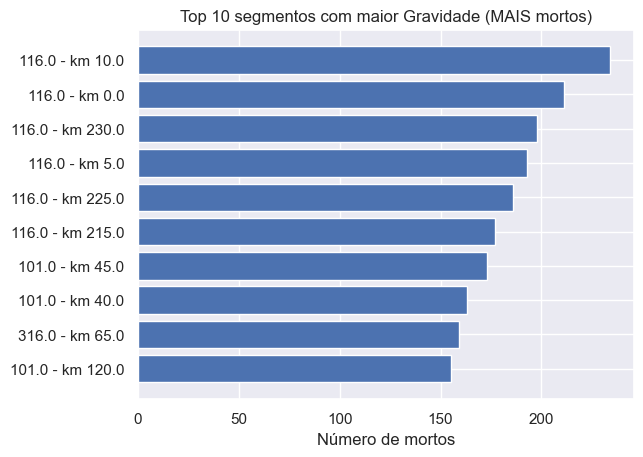

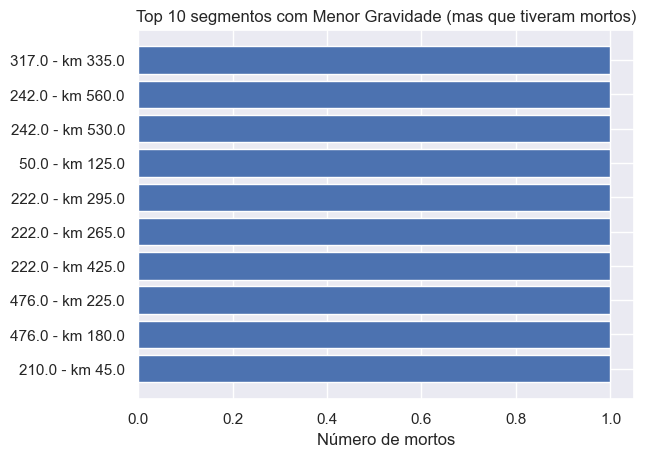

In [41]:
import matplotlib.pyplot as plt

# =============================
# 1️⃣ Filtrar apenas acidentes com mortos
# =============================

df_mortos = df_segmento[df_segmento["gravidade"] == "Acidente com mortos"].copy()

# Ordenar por número de mortos
df_mortos = df_mortos.sort_values("total_mortos", ascending=False)

# =============================
# 2️⃣ Top 10 com mais mortos
# =============================

top10_mortos = df_mortos.head(10)

top10_mortos["segmento"] = (
    top10_mortos["br"].astype(str) + " - km " +
    top10_mortos["km_bin"].astype(str)
)

plt.figure()

plt.barh(
    top10_mortos["segmento"],
    top10_mortos["total_mortos"]
)

plt.xlabel("Número de mortos")
plt.title("Top 10 segmentos com maior Gravidade (MAIS mortos)")
plt.gca().invert_yaxis()

plt.show()


# =============================
# 3️⃣ 10 segmentos com menos mortos
# =============================

menos_mortos = df_mortos.tail(10).sort_values("total_mortos")

menos_mortos["segmento"] = (
    menos_mortos["br"].astype(str) + " - km " +
    menos_mortos["km_bin"].astype(str)
)

plt.figure()

plt.barh(
    menos_mortos["segmento"],
    menos_mortos["total_mortos"]
)

plt.xlabel("Número de mortos")
plt.title("Top 10 segmentos com Menor Gravidade (mas que tiveram mortos)")
plt.gca().invert_yaxis()

plt.show()

In [42]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster

# =============================
# 1️⃣ Preparar dados
# =============================

cols = ["latitude", "longitude", "km"]

for col in cols:
    df_map[col] = (
        df_map[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )
    df_map[col] = pd.to_numeric(df_map[col], errors="coerce")

df_map = df_map.dropna(subset=["latitude", "longitude"])

# =============================
# 🚨 FILTRAR APENAS ACIDENTES GRAVES
# =============================

df_map = df_map[df_map["mortos"] > 0]

# =============================
# Índice de severidade
# =============================

df_map["severity_index"] = (
    4 * df_map["mortos"] +
    2 * df_map["feridos_graves"] +
    1 * df_map["feridos_leves"]
)

# =============================
# Criar segmentos de 5 km
# =============================

df_map["km_bin"] = (df_map["km"] // 5) * 5

# =============================
# Agrupar segmentos
# =============================

df_segmento = df_map.groupby(["br", "km_bin"]).agg(
    severity_index=("severity_index", "mean"),
    n_acidentes=("severity_index", "count"),
    total_mortos=("mortos", "sum"),
    total_feridos_graves=("feridos_graves", "sum"),
    total_feridos_leves=("feridos_leves", "sum")
).reset_index()

df_segmento["taxa_mortalidade"] = (
    df_segmento["total_mortos"] /
    df_segmento["n_acidentes"]
)

# =============================
# 🚗 CLASSIFICAÇÃO DE VEÍCULOS
# =============================

caminhao = [
    "Caminhão",
    "Caminhão-trator"
]

veiculos_leves = [
    "Automóvel",
    "Caminhonete",
    "Camioneta",
    "Utilitário",
    "Motocicleta",
    "Motoneta",
    "Ciclomotor",
    "Triciclo",
    "Quadriciclo"
]

# =============================
# 2️⃣ Criar mapa
# =============================

m = folium.Map(
    location=[df_map["latitude"].mean(), df_map["longitude"].mean()],
    zoom_start=6
)

# Camadas
layer_todos = folium.FeatureGroup(name="🔴 Todos acidentes graves")
layer_caminhao = folium.FeatureGroup(name="🚛 Acidentes com caminhão")
layer_leve = folium.FeatureGroup(name="🚗 Acidentes com veículos leves")

cluster_todos = MarkerCluster().add_to(layer_todos)
cluster_caminhao = MarkerCluster().add_to(layer_caminhao)
cluster_leve = MarkerCluster().add_to(layer_leve)

m.add_child(layer_todos)
m.add_child(layer_caminhao)
m.add_child(layer_leve)

# =============================
# 3️⃣ Adicionar pontos
# =============================

for _, row in df_segmento.iterrows():

    segment = df_map[
        (df_map["br"] == row["br"]) &
        (df_map["km_bin"] == row["km_bin"])
    ]

    if segment.empty:
        continue

    lat = segment["latitude"].mean()
    lon = segment["longitude"].mean()

    if np.isnan(lat) or np.isnan(lon):
        continue

    veiculos_count = segment["tipo_veiculo"].value_counts()

    # detectar tipo dominante
    tem_caminhao = segment["tipo_veiculo"].isin(caminhao).any()
    tem_leve = segment["tipo_veiculo"].isin(veiculos_leves).any()

    if not veiculos_count.empty:
        top3 = veiculos_count.head(3)

        veiculo_html = "<br>".join(
            [f"{v}: {c}" for v, c in top3.items()]
        )
    else:
        veiculo_html = "Sem dados"

    popup_text = f"""
<div style="
    font-family: Arial;
    font-size: 13px;
    width: 260px;
">

<h4 style="margin-bottom:5px;color:#2c3e50;">
 Informações do Segmento
</h4>

<b>Rodovia:</b> BR-{row['br']} <br>
<b>Segmento:</b> km {row['km_bin']}  

<hr style="margin:6px 0">

<h4 style="margin-bottom:4px;color:#c0392b;">
 Dados do Acidente
</h4>

<b>Acidentes graves:</b> {row['n_acidentes']} <br>
<b>Mortos:</b> {row['total_mortos']} <br>
<b>Feridos graves:</b> {row['total_feridos_graves']} <br>
<b>Feridos leves:</b> {row['total_feridos_leves']}

<hr style="margin:6px 0">

<h4 style="margin-bottom:4px;color:#8e44ad;">
 Indicadores
</h4>

<b>Severidade média:</b> {row['severity_index']:.2f} <br>
<b>Taxa de mortalidade:</b> {row['taxa_mortalidade']:.2f}

<hr style="margin:6px 0">

<h4 style="margin-bottom:4px;color:#2980b9;">
🚗 Veículos mais envolvidos
</h4>

{veiculo_html}

</div>
"""

    circle = folium.Circle(
        location=[lat, lon],
        radius=row["n_acidentes"] * 60,
        color="red",
        fill=True,
        fill_opacity=0.6,
        popup=folium.Popup(popup_text, max_width=300)
    )

    circle.add_to(cluster_todos)

    if tem_caminhao:
        folium.Circle(
            location=[lat, lon],
            radius=row["n_acidentes"] * 60,
            color="purple",
            fill=True,
            fill_opacity=0.6,
            popup=popup_text
        ).add_to(cluster_caminhao)

    if tem_leve:
        folium.Circle(
            location=[lat, lon],
            radius=row["n_acidentes"] * 60,
            color="blue",
            fill=True,
            fill_opacity=0.6,
            popup=popup_text
        ).add_to(cluster_leve)

# =============================
# Controle de camadas
# =============================

folium.LayerControl(collapsed=False).add_to(m)

m.save("mapa_acidentes_graves_filtro.html")

print("Mapa salvo como mapa_acidentes_graves_filtro.html")

Mapa salvo como mapa_acidentes_graves_filtro.html


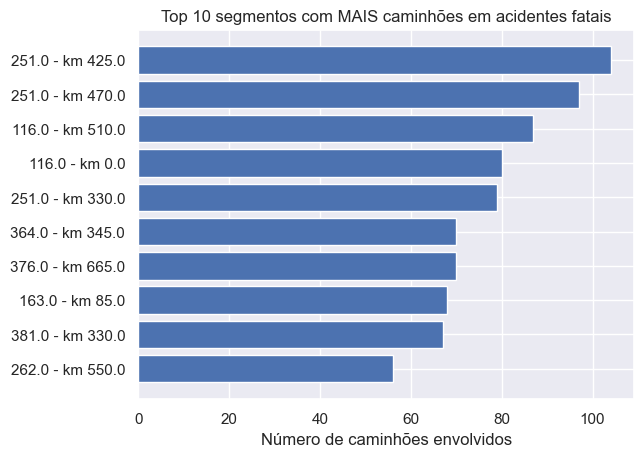

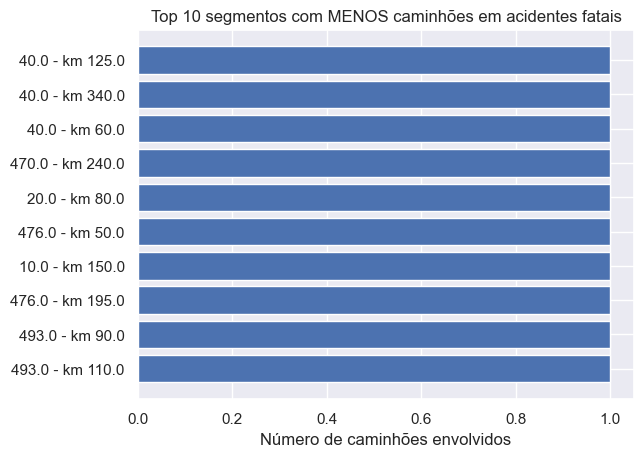

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# =============================
# 🚛 Veículos de caminhão
# =============================

caminhao = ["Caminhão", "Caminhão-trator"]

# =============================
# 1️⃣ Filtrar acidentes com mortos
# =============================

df_mortos = df_map[df_map["mortos"] > 0].copy()

# =============================
# 2️⃣ Filtrar apenas caminhões
# =============================

df_caminhao = df_mortos[df_mortos["tipo_veiculo"].isin(caminhao)].copy()

# =============================
# 3️⃣ Contar caminhões por segmento
# =============================

df_caminhao_seg = df_caminhao.groupby(
    ["br", "km_bin"]
).size().reset_index(name="n_caminhoes")

# Criar nome do segmento
df_caminhao_seg["segmento"] = (
    df_caminhao_seg["br"].astype(str) +
    " - km " +
    df_caminhao_seg["km_bin"].astype(str)
)

# Ordenar
df_caminhao_seg = df_caminhao_seg.sort_values(
    "n_caminhoes",
    ascending=False
)

# =============================
# 4️⃣ Top 10 MAIS caminhões
# =============================

top10 = df_caminhao_seg.head(10)

plt.figure()

plt.barh(
    top10["segmento"],
    top10["n_caminhoes"]
)

plt.xlabel("Número de caminhões envolvidos")
plt.title("Top 10 segmentos com MAIS caminhões em acidentes fatais")

plt.gca().invert_yaxis()

plt.show()

# =============================
# 5️⃣ 10 MENOS caminhões
# =============================

menos10 = df_caminhao_seg.tail(10).sort_values("n_caminhoes")

plt.figure()

plt.barh(
    menos10["segmento"],
    menos10["n_caminhoes"]
)

plt.xlabel("Número de caminhões envolvidos")
plt.title("Top 10 segmentos com MENOS caminhões em acidentes fatais")

plt.gca().invert_yaxis()

plt.show()

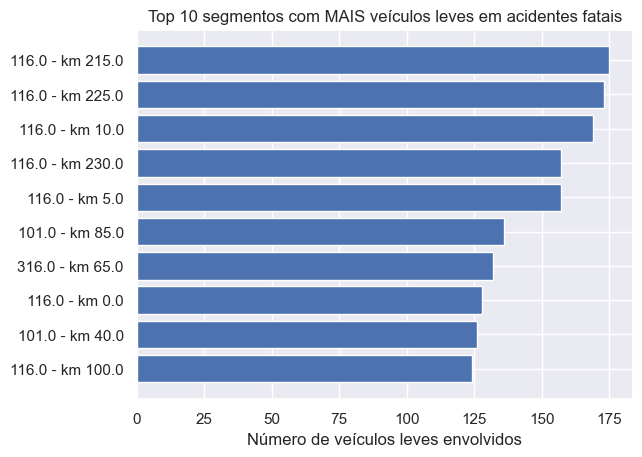

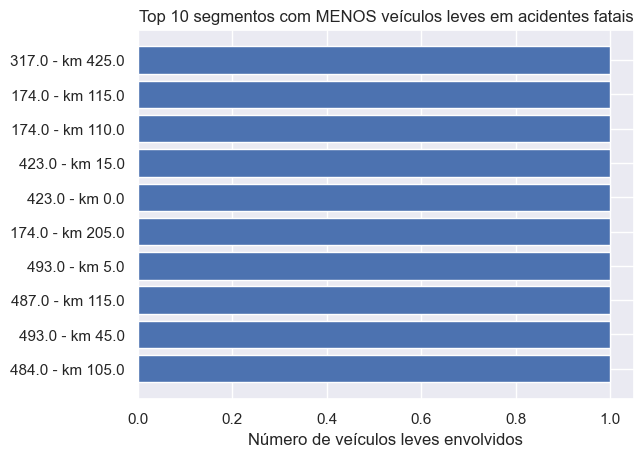

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# =============================
# 🚗 Veículos leves
# =============================

veiculos_leves = [
    "Automóvel",
    #
    "Caminhonete",
    "Camioneta",
    "Utilitário",
    #
    "Motocicleta",
    "Motoneta",
    #
    "Ciclomotor",
    "Triciclo",
    "Quadriciclo"
]

# =============================
# 1️⃣ Filtrar acidentes com mortos
# =============================

df_mortos = df_map[df_map["mortos"] > 0].copy()

# =============================
# 2️⃣ Filtrar apenas veículos leves
# =============================

df_leves = df_mortos[df_mortos["tipo_veiculo"].isin(veiculos_leves)].copy()

# =============================
# 3️⃣ Contar veículos leves por segmento
# =============================

df_leves_seg = df_leves.groupby(
    ["br", "km_bin"]
).size().reset_index(name="n_veiculos_leves")

# Criar nome do segmento
df_leves_seg["segmento"] = (
    df_leves_seg["br"].astype(str) +
    " - km " +
    df_leves_seg["km_bin"].astype(str)
)

# Ordenar
df_leves_seg = df_leves_seg.sort_values(
    "n_veiculos_leves",
    ascending=False
)

# =============================
# 4️⃣ Top 10 MAIS veículos leves
# =============================

top10 = df_leves_seg.head(10)

plt.figure()

plt.barh(
    top10["segmento"],
    top10["n_veiculos_leves"]
)

plt.xlabel("Número de veículos leves envolvidos")
plt.title("Top 10 segmentos com MAIS veículos leves em acidentes fatais")

plt.gca().invert_yaxis()

plt.show()

# =============================
# 5️⃣ 10 MENOS veículos leves
# =============================

menos10 = df_leves_seg.tail(10).sort_values("n_veiculos_leves")

plt.figure()

plt.barh(
    menos10["segmento"],
    menos10["n_veiculos_leves"]
)

plt.xlabel("Número de veículos leves envolvidos")
plt.title("Top 10 segmentos com MENOS veículos leves em acidentes fatais")

plt.gca().invert_yaxis()

plt.show()

In [45]:
# =============================
# 📊 Totais gerais
# =============================

total_acidentes = len(df)
total_segmentos = len(df_segmento)

print("Total de acidentes no dataset:", total_acidentes)
print("Total de segmentos analisados:", total_segmentos)

Total de acidentes no dataset: 1673522
Total de segmentos analisados: 5182


In [46]:
print("Shape inicial:", df.shape)

Shape inicial: (1673522, 53)
